In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('classic')
import numpy as np
import argparse
import os

sns.set()

In [2]:
print(f"Old Directory: {os.getcwd()}")
os.chdir(r'../')
print(f"New Directory: {os.getcwd()}")

Old Directory: d:\GitHub\Sala_Situacion_Dinagua\Status_Outlook_Bulletin\notebook
New Directory: d:\GitHub\Sala_Situacion_Dinagua\Status_Outlook_Bulletin


In [3]:
'''
# Define arguments 
parser = argparse.ArgumentParser(
                    prog='calculate_hydrological_status',
                    description='Calculates monthly hydrological status from observation point',
                    epilog='Jose Valles, DINAGUA, 26082024')

# 
parser.add_argument('month_analysis', help='provide the input time series frequency (daily or monthly)')
parser.add_argument('year_analysis', help='input directory, should ONLY contain .csv daily flow timeseries')        


args = parser.parse_args()
'''
args = argparse.Namespace(
    month_analysis='03',
    year_analysis='2026',
)

In [4]:
BASIN_LEVEL3 = pd.read_csv(f'./waterbalance/balance_hidrico_regional/output_modelo/cuenca_nivel3.csv',index_col="Codigo")
BASIN_LEVEL2 = pd.read_csv(f'./waterbalance/balance_hidrico_regional/output_modelo/cuenca_nivel2.csv',index_col="Codigo")

In [5]:
def importmodelvariable(model_variable):
    df = pd.read_csv(f'./waterbalance/balance_hidrico_regional/output_modelo/{model_variable}.csv')
    df = df.rename(columns={'-1': 'year','-1.1':'month'})
    df['date'] = pd.to_datetime(dict(year=df['year'],month=df['month'],day=1))
    df = df.set_index('date')
    df['days_in_month'] = df.index.days_in_month
    return df

def convertRunoff2Discharge(df_runoff):
    # Drop metadata columns to get only spatial sub-basin columns
    data_cols = df_runoff.drop(columns=['year', 'month', 'days_in_month'])

    # Convert runoff [mm] to discharge [m³/s] in one vectorised operation:
    #   runoff_mm * 1000 * area_km2 -> volume_m3 per month
    #   volume_m3 / (days_in_month * 86400) -> m³/s
    seconds_in_month = (df_runoff['days_in_month'].values * 86400)[:, None]  # shape (n_rows, 1) for broadcasting
    discharge_values = (data_cols.values * 1000 * BASIN_LEVEL3.values) / seconds_in_month

    df_discharge = pd.DataFrame(discharge_values, index=df_runoff.index, columns=data_cols.columns)
    df_discharge['year'] = df_runoff['year'].values
    df_discharge['month'] = df_runoff['month'].values
    return df_discharge

def defineHydroSOScategory(VARIABLE_MENSUAL, VARIABLE_AVERAGE, VARIABLE):
    # Work on a copy to avoid mutating the caller's DataFrame
    result = VARIABLE_MENSUAL.copy()

    # --- Vectorised month-wise ranking (replaces the slow row-by-row loop) ---
    # groupby('month') operates on all rows of the same calendar month at once,
    # so rank() and transform() are called 12 times instead of n_rows times.
    result['rank_average'] = result.groupby('month')[VARIABLE].rank()
    result['non_missing'] = result.groupby('month')[VARIABLE].transform(lambda s: s.notna().sum())

    # Map climatological mean to every row via the month key (avoids repeated .query())
    # VARIABLE_AVERAGE is indexed by month after groupby, so .map() is a single dict lookup.
    result['mean'] = result['month'].map(VARIABLE_AVERAGE[VARIABLE])
    result['average_percentage'] = (result[VARIABLE] - result['mean']) / result['mean']

    # Percentile position using the Weibull plotting position formula
    result['percentile'] = result['rank_average'] / (result['non_missing'] + 1)

    # Classify into HydroSOS categories using vectorised np.select (no Python loop)
    criteria = [
        (result['percentile'] > 0.90) & (result['percentile'] <= 1.00),
        (result['percentile'] > 0.75) & (result['percentile'] <= 0.90),
        (result['percentile'] >= 0.25) & (result['percentile'] <= 0.75),
        (result['percentile'] >= 0.10) & (result['percentile'] <  0.25),
        (result['percentile'] >= 0.00) & (result['percentile'] <  0.10),
    ]
    values = ['High flow', 'Above normal', 'Normal range', 'Below normal', 'Low flow']
    result['percentile_range'] = np.select(criteria, values, default=None)
    return result


In [6]:
hydrological_variable = ['Escorrentia_total','Escorrentia_sup','Escorrentia_sub','Pmedias','ETR','HumedadSuelo']

In [7]:
_vars = {name: importmodelvariable(name) for name in hydrological_variable}

RUNOFF_total = _vars['Escorrentia_total']
RUNOFF_sup   = _vars['Escorrentia_sup']
RUNOFF_sub   = _vars['Escorrentia_sub']
PRECIP       = _vars['Pmedias']
ETR          = _vars['ETR']
SM           = _vars['HumedadSuelo']

In [8]:
DISCHARGE = convertRunoff2Discharge(RUNOFF_total)

In [9]:
RUNOFF = RUNOFF_total

In [10]:
# ## Calculate the percentage of anomaly for each basin code level 2 and a specific month and year
month_analyis = int(args.month_analysis)
year_analysis = int(args.year_analysis)

year_start = 1981
year_end = 2010

# Reference-period boolean mask (same for all variables since they share the same time axis)
# Computed once here and reused inside the basin loop — avoids rebuilding it per basin.
ref_mask      = (DISCHARGE['year'] >= year_start) & (DISCHARGE['year'] <= year_end)
analysis_mask = (DISCHARGE['month'] == month_analyis) & (DISCHARGE['year'] == year_analysis)

# Shared year/month columns — copied once and reused inside the loop.
base_ym = DISCHARGE[['year', 'month']].copy()

# Precompute which level-3 model columns belong to each level-2 basin.
# Without this, every basin iteration scans ALL model columns via startswith() —
# this single dict lookup replaces that O(basins × columns) scan.
model_cols = [c for c in DISCHARGE.columns if c not in ('year', 'month')]
basin_cols_map = {
    basin: [c for c in model_cols if str(c).startswith(str(basin))]
    for basin in BASIN_LEVEL2.columns
}

# Use basin code as the DataFrame index so assignment is a direct .at[basin, col]
# lookup instead of a boolean-scan eval() call per row.
# The index is named 'codigo' so reset_index() at the end always produces that column.
AVERAGE_PERCENTAGE = pd.DataFrame(
    index=pd.Index(BASIN_LEVEL2.columns, name='codigo'),
    columns=['discharge', 'runoff', 'precip', 'precip_val', 'hydroSOS_category'],
    dtype=object
)
AVERAGE_PERCENTAGE[['discharge', 'runoff', 'precip', 'precip_val']] = np.nan

In [11]:
for basin in BASIN_LEVEL2.columns:
    # Retrieve precomputed sub-basin column list for this level-2 basin
    filter_col = basin_cols_map[basin]
    if not filter_col:
        continue

    # --- Aggregate sub-basin values to level-2 basin time series ---
    # base_ym is shared across all basins; we assign the aggregated value column only.
    # Discharge: sum of sub-basins (total river flow)
    DISCHARGE_SELECTED = base_ym.copy()
    DISCHARGE_SELECTED['discharge'] = DISCHARGE[filter_col].sum(axis=1)

    # Runoff: spatial mean across sub-basins (area-normalised)
    RUNOFF_SELECTED = base_ym.copy()
    RUNOFF_SELECTED['runoff'] = RUNOFF[filter_col].mean(axis=1)

    # Precipitation: spatial mean across sub-basins
    PRECIP_SELECTED = base_ym.copy()
    PRECIP_SELECTED['precip'] = PRECIP[filter_col].mean(axis=1)

    # --- Climatological normals (1981-2010 reference period) ---
    # ref_mask was computed once before the loop (avoids rebuilding per basin)
    DISCHARGE_AVERAGE = DISCHARGE_SELECTED.loc[ref_mask].groupby('month')[['discharge']].mean()
    RUNOFF_AVERAGE    = RUNOFF_SELECTED.loc[ref_mask].groupby('month')[['runoff']].mean()
    PRECIP_AVERAGE    = PRECIP_SELECTED.loc[ref_mask].groupby('month')[['precip']].mean()

    # --- HydroSOS classification (vectorised inside defineHydroSOScategory) ---
    hydroSOS = defineHydroSOScategory(DISCHARGE_SELECTED, DISCHARGE_AVERAGE, 'discharge')

    # --- Extract scalar values for the analysis month/year ---
    # analysis_mask is a pre-built boolean array; iloc[0] is a single scalar read.
    val_discharge = DISCHARGE_SELECTED.loc[analysis_mask, 'discharge'].iloc[0]
    val_runoff    = RUNOFF_SELECTED.loc[analysis_mask, 'runoff'].iloc[0]
    val_precip    = PRECIP_SELECTED.loc[analysis_mask, 'precip'].iloc[0]
    val_category  = hydroSOS.loc[analysis_mask, 'percentile_range'].iloc[0]

    clim_discharge = DISCHARGE_AVERAGE.at[month_analyis, 'discharge']
    clim_runoff    = RUNOFF_AVERAGE.at[month_analyis, 'runoff']
    clim_precip    = PRECIP_AVERAGE.at[month_analyis, 'precip']

    # --- Write results using direct index access (no eval/query row scan) ---
    AVERAGE_PERCENTAGE.at[basin, 'discharge']         = (val_discharge - clim_discharge) / clim_discharge
    AVERAGE_PERCENTAGE.at[basin, 'runoff']            = (val_runoff    - clim_runoff)    / clim_runoff
    AVERAGE_PERCENTAGE.at[basin, 'precip']            = (val_precip    - clim_precip)    / clim_precip
    AVERAGE_PERCENTAGE.at[basin, 'precip_val']        = val_precip
    AVERAGE_PERCENTAGE.at[basin, 'hydroSOS_category'] = val_category
    # AVERAGE_PERCENTAGE.at[basin, 'percentile'] = hydroSOS.loc[analysis_mask, 'percentile'].iloc[0]

# Reset index so 'codigo' becomes a regular column (matches downstream chart code)
AVERAGE_PERCENTAGE = AVERAGE_PERCENTAGE.reset_index()

In [12]:
AVERAGE_PERCENTAGE.to_csv('./qgis_status_outlook/csvtables/modelling_result_codcuenca_2.csv',index=False)

In [13]:
AVERAGE_PERCENTAGE.to_json(f'./waterbalance/output_json/output_variables/{args.year_analysis}-{args.month_analysis}.json', orient='records', lines=False)

In [16]:
# Count basin occurrences per HydroSOS category
category_counts = AVERAGE_PERCENTAGE['hydroSOS_category'].value_counts()

# Area-weighted category share (% of total basin area)
BASIN_LEVEL2.loc['Area'] = BASIN_LEVEL2.loc['Area'].astype(float)
total_area = BASIN_LEVEL2.loc['Area', AVERAGE_PERCENTAGE['codigo']].sum()
category_counts_area = AVERAGE_PERCENTAGE.groupby('hydroSOS_category')['codigo'].apply(
    lambda x: BASIN_LEVEL2.loc['Area', x].sum() / total_area * 100
)

In [17]:
# Definir los colores para cada categoría basados en el estado hidrológico
colors = [
    '#2C7DCD' if category == 'High flow' else
    '#8ECEEE' if category == 'Above normal' else
    '#E7E2BC' if category == 'Normal range' else
    '#FFA885' if category == 'Below normal' else
    '#CD233F'  # Low flow
    for category in category_counts_area.index
]

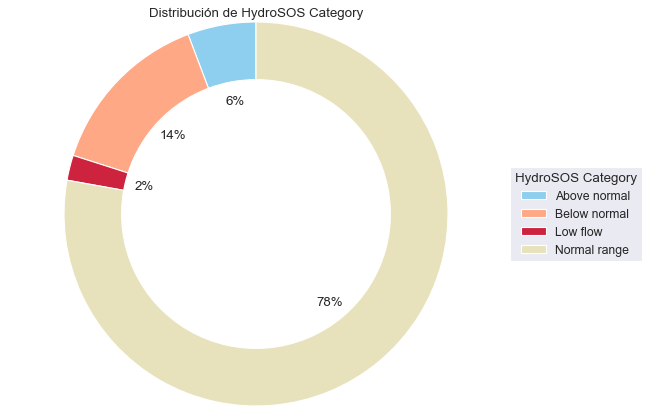

In [18]:
# Crear el gráfico de doughnut
fig, ax = plt.subplots()
ax.pie(category_counts_area, labels=None, autopct='%1.0f%%', startangle=90, wedgeprops={'width': 0.3}, colors=colors)

# Asegurar que el gráfico sea un círculo
ax.axis('equal')

# Añadir leyenda con los nombres de las categorías
plt.legend(category_counts_area.index, title="HydroSOS Category", loc="center left", bbox_to_anchor=(1, 0.5))

# Título del gráfico
plt.title('Distribución de HydroSOS Category')

# Mostrar el gráfico
plt.show()